<a href="https://colab.research.google.com/github/sheicksen/CISC483-EngageTactics/blob/JiaQi-RNN-Implementation/Truthseeker_RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Attempted RNN Implementation

- RNN useful when the order of sentence matter
- RNN has use in sentiment classification (words that go with certain emotions), want to extend this to fake news
- Want to be able to predict real/fake news, associating certain words with fake news

In [3]:
import os
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from google.colab import files

In [5]:
uploaded = files.upload()

# Assuming you upload a file named 'your_file_name.csv'
# You will need to replace 'your_file_name.csv' with the actual name of your uploaded file.

Saving Truth_Seeker_Model_Dataset.csv to Truth_Seeker_Model_Dataset.csv


In [6]:
# Get the name of the uploaded file(s)
# This assumes only one file is uploaded. If multiple, you'll need to choose the correct one.
for fn in uploaded.keys():
  print(f'User uploaded file "{fn}"')
  truthseeker_df = pd.read_csv(io.StringIO(uploaded[fn].decode('utf-8')))

# Display the first few rows of the DataFrame, shape and headers
#display(truthseeker_df.head())
print(truthseeker_df.shape)

# print(truthseeker_df['tweet'][0])
print(truthseeker_df.info()) # print df info

User uploaded file "Truth_Seeker_Model_Dataset.csv"
(134198, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134198 entries, 0 to 134197
Data columns (total 9 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Unnamed: 0               134198 non-null  int64  
 1   author                   134198 non-null  object 
 2   statement                134198 non-null  object 
 3   target                   134198 non-null  bool   
 4   BinaryNumTarget          134198 non-null  float64
 5   manual_keywords          134198 non-null  object 
 6   tweet                    134198 non-null  object 
 7   5_label_majority_answer  134198 non-null  object 
 8   3_label_majority_answer  134198 non-null  object 
dtypes: bool(1), float64(1), int64(1), object(6)
memory usage: 8.3+ MB
None


In [ ]:
# View the distribution of answers in the '3_label_majority_answer' column
display(truthseeker_df['3_label_majority_answer'].value_counts())

,count
3_label_majority_answer,
Agree,128471
Disagree,5727


In [7]:
# Define target (y) and features (X)

# Combine 'tweet' and 'statement' columns to provide more context
# A separator like '[SEP]' can be useful to distinguish between the two parts
# X = truthseeker_df['tweet'] + " [SEP] " + truthseeker_df['statement']

# Version with no separator
X = truthseeker_df['tweet']

# Define the new target 'y' by XORing '3_label_majority_answer' (converted to binary) with 'BinaryNumTarget'
# We'll assume 'Agree' from '3_label_majority_answer' means 0 and disagree means 1
y_3_label_binary = (truthseeker_df['3_label_majority_answer'] != 'Agree').astype(int)

# Perform the XOR operation. Ensure both are integers for bitwise XOR.
# Here 1 = true news and 0 = fake news
y = (y_3_label_binary ^ truthseeker_df['BinaryNumTarget'].astype(int))
print("Distribution of y:")
print(y.value_counts()) # distribution of 1s and 0s

# at 0.01, with high epoch, saw clear overfitting
sample_fraction = 0.25 # Adjust this value to change the sample size

# Sample the data before splitting
X_sample, y_sample = X.sample(frac=sample_fraction, random_state=42), y.sample(frac=sample_fraction, random_state=42)

# split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_sample, y_sample, test_size=0.2, random_state=42, stratify=y_sample)

print("Distribution of y_train:")
print(y_train.value_counts()) # distribution of 1s and 0s
print("Distribution of y_test:")
print(y_test.value_counts()) # distribution of 1s and 0s

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Distribution of y:
1    68985
0    65213
Name: count, dtype: int64
Distribution of y_train:
1    13869
0    12971
Name: count, dtype: int64
Distribution of y_test:
1    3467
0    3243
Name: count, dtype: int64
X_train shape: (26840,)
X_test shape: (6710,)
y_train shape: (26840,)
y_test shape: (6710,)


In [8]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import re # Import regular expression module

# Function to remove mentions
def remove_mentions(text):
    return re.sub(r'@\S+', '', text)

# Apply the function to X to clean mentions before fitting the tokenizer
X_cleaned = X.apply(remove_mentions)
print("Cleaned entry:", X_cleaned[1])

# Parameters for tokenization and padding
VOCAB_SIZE = 10000  # Max number of words to keep, based on word frequency
MAX_SEQUENCE_LENGTH = 150 # Max length of each tweet sequence

# Initialize tokenizer
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")

# Fit tokenizer on the cleaned combined text
tokenizer.fit_on_texts(X_cleaned)

# Apply mention removal to X_train and X_test before converting to sequences
X_train_cleaned = X_train.apply(remove_mentions)
X_test_cleaned = X_test.apply(remove_mentions)

# Convert text to sequences of numbers using the fitted tokenizer
training_sequences = tokenizer.texts_to_sequences(X_train_cleaned)
testing_sequences = tokenizer.texts_to_sequences(X_test_cleaned)

# Pad sequences to ensure uniform length
padded_training_sequences = pad_sequences(training_sequences, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')
padded_testing_sequences = pad_sequences(testing_sequences, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')

print(f"Shape of padded training sequences: {padded_training_sequences.shape}")
print(f"Shape of padded testing sequences: {padded_testing_sequences.shape}")
# each number is an ID for that word, assigned by tokenizer
print(f"Example of a padded sequence:\n{padded_training_sequences[1]}")
print(f"Vocabulary size: {len(tokenizer.word_index)}")

Cleaned entry:    Not as many people are literally starving and out in the streets as they were in the 19th century. Isnt capitalism grand?

Meanwhile, were facing an eviction moratorium threatening to make millions of Americans homeless.

Fuck off with this corporatist propaganda.
Shape of padded training sequences: (26840, 150)
Shape of padded testing sequences: (6710, 150)
Example of a padded sequence:
[   2  344   70  422    8  113    7  300  619    7    2 3013  802    8
   64 2184  274   27   97    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0   

In [9]:
# Calculate the length of each tweet
tweet_lengths = truthseeker_df['tweet'].apply(len)

# Print some stats on length
print(f"Mean tweet length: {tweet_lengths.mean():.2f}")
print(f"Max tweet length: {tweet_lengths.max()}")
print(f"Median tweet length: {tweet_lengths.median()}")
print(f"Min tweet length: {tweet_lengths.min()}")

Mean tweet length: 217.31
Max tweet length: 993
Median tweet length: 231.0
Min tweet length: 6


This `tokenizer.json` file can later be loaded to reconstruct the exact same tokenizer, which is crucial for using the trained model with new, unseen text data consistently.

The `padded_sequences` now contain the numerical representation of your tweets, ready to be fed into an embedding layer. Each number corresponds to a word in the tokenizer's vocabulary. The next step would typically involve creating a Keras Embedding layer as part of an RNN model.

In [10]:
import json

# Save the tokenizer configuration to a JSON file
tokenizer_json = tokenizer.to_json()
with open('tokenizer.json', 'w', encoding='utf-8') as f:
    f.write(json.dumps(tokenizer_json, ensure_ascii=False))

print("Tokenizer saved to tokenizer.json")

Tokenizer saved to tokenizer.json


### Incorporating Pre-trained Word Embeddings (word2vec)

To improve the model's performance, especially with limited data, we can use pre-trained word embeddings. These embeddings capture semantic relationships between words based on large text corpora. We will use word2vec embeddings as an example.

In [ ]:
# Install gensim if not already installed.
# Using %pip in a cell ensures it's installed in the Colab environment.
%pip install gensim

import gensim.downloader as api
import gensim.models

# Download a pre-trained Word2Vec model
# 'word2vec-google-news-300' corresponds to GoogleNews-vectors-negative300.bin.
# This is a large file (approx 1.6GB), so it might take some time.
print("Downloading Word2Vec model. This may take a while...")
word2vec_model = api.load("word2vec-google-news-300")
print("Word2Vec model loaded.")

# Assign the loaded Word2Vec model to embeddings_index for compatibility
# gensim's KeyedVectors object (word2vec_model) can be directly used like a dictionary
# to get vectors, which is compatible with the subsequent embedding matrix creation.
embeddings_index = word2vec_model

print(f'Found {len(embeddings_index.key_to_index)} word vectors.')

Word2Vec model loaded.
Found 3000000 word vectors.


In [ ]:
# Save the Word2Vec model to disk
model_save_path = 'word2vec-google-news-300.bin'
word2vec_model.save(model_save_path)
print(f"Word2Vec model saved to {model_save_path}")

Word2Vec model saved to word2vec-google-news-300.bin


You can load the saved model in a future session using:
```python
import gensim.models
loaded_word2vec_model = gensim.models.KeyedVectors.load('word2vec-google-news-300.bin')
embeddings_index = loaded_word2vec_model # for compatibility with existing code
```

In [26]:
import gensim.models
import gensim.downloader as api
import os # To check if file exists

model_path = 'word2vec-google-news-300.bin'

try:
    loaded_word2vec_model = gensim.models.KeyedVectors.load(model_path)
    print("Word2Vec model loaded from saved file.")
except Exception as e:
    # If loading fails, it might be due to a corrupted or incomplete file.
    # Attempt to re-download the model.
    print(f"Error loading saved Word2Vec model: {e}. Attempting to re-download.")
    print("Downloading Word2Vec model. This may take a while...")
    word2vec_model = api.load("word2vec-google-news-300")
    print("Word2Vec model re-downloaded.")

    # Save the re-downloaded model for future use
    word2vec_model.save(model_path)
    print(f"Word2Vec model re-saved to {model_path}")

    loaded_word2vec_model = word2vec_model # Assign the re-downloaded model

embeddings_index = loaded_word2vec_model # for compatibility with existing code

KeyboardInterrupt: 

Now, we'll create an embedding matrix that we can use to initialize our Keras Embedding layer. This matrix will contain the word2vec vectors for the words present in our tokenizer's vocabulary.

In [53]:
# Create an embedding matrix
EMBEDDING_DIM = 300 # Word2Vec Google News vectors are 300-dimensional

embedding_matrix = np.zeros((VOCAB_SIZE, EMBEDDING_DIM))
for word, i in tokenizer.word_index.items():
    if i < VOCAB_SIZE:
        # Check if the word exists in the Word2Vec model's vocabulary
        if word in embeddings_index: # embeddings_index is now the Word2Vec KeyedVectors object
            embedding_vector = embeddings_index[word] # Access vector directly
            embedding_matrix[i] = embedding_vector

print(f'Shape of embedding matrix: {embedding_matrix.shape}')
print(embedding_matrix)

Shape of embedding matrix: (10000, 300)
[[ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 0.08007812  0.10498047  0.04980469 ...  0.00366211  0.04760742
  -0.06884766]
 ...
 [-0.02441406  0.0625     -0.07763672 ...  0.21582031 -0.22949219
   0.04101562]
 [ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ...  0.          0.
   0.        ]]


In [48]:
zero_rows = np.all(embedding_matrix == 0, axis=1)
num_zero_rows = np.sum(zero_rows)

print(f"Number of rows with all zeros in the embedding matrix: {num_zero_rows}")
print(f"This means {num_zero_rows} words from your vocabulary did not have a pre-trained embedding in the Word2Vec model and were initialized to zeros.")

Number of rows with all zeros in the embedding matrix: 912
This means 912 words from your vocabulary did not have a pre-trained embedding in the Word2Vec model and were initialized to zeros.


Now, we will modify the RNN model to use this pre-trained embedding matrix. We'll set `trainable=True` to allow for fine-tuning the embeddings on our specific dataset.

In [54]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# Define the LSTM model with pre-trained embeddings, bidirectional so it analyzes tweet from both directions
model_pretrained_embedding = Sequential([
    Embedding(VOCAB_SIZE, EMBEDDING_DIM, weights=[embedding_matrix], trainable=True),
    Bidirectional(LSTM(units=64)),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile the model, adjusting how fast it learns through optimizer
optimizer = Adam(learning_rate=0.01)
model_pretrained_embedding.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy', 'f1_score'])

# Print model summary
model_pretrained_embedding.summary()

# Define EarlyStopping callback
# It monitors 'val_loss' and stops if it doesn't improve for 3 consecutive epochs.
# 'restore_best_weights' ensures the model keeps the weights from the epoch with the best validation loss.
early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

# Retrain the model with early stopping
# Reusing the early_stopping callback defined previously
history_pretrained = model_pretrained_embedding.fit(
    padded_training_sequences,
    y_train,
    epochs=5, # Start with a reasonable number of epochs
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping]
)

print("Model training with pre-trained embeddings complete.")

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)         │ ?                      │     3,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,000,000 (11.44 MB)

 Trainable params: 3,000,000 (11.44 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
671/671 ━━━━━━━━━━━━━━━━━━━━ 275s 403ms/step - accuracy: 0.8826 - f1_score: 0.6802 - loss: 0.3189 - val_accuracy: 0.9041 - val_f1_score: 0.6859 - val_loss: 0.2946
Epoch 2/5
671/671 ━━━━━━━━━━━━━━━━━━━━ 281s 418ms/step - accuracy: 0.9358 - f1_score: 0.6802 - loss: 0.2140 - val_accuracy: 0.9048 - val_f1_score: 0.6859 - val_loss: 0.3020
Epoch 3/5
671/671 ━━━━━━━━━━━━━━━━━━━━ 309s 399ms/step - accuracy: 0.9423 - f1_score: 0.6802 - loss: 0.1888 - val_accuracy: 0.9013 - val_f1_score: 0.6859 - val_loss: 0.2993
Epoch 4/5
671/671 ━━━━━━━━━━━━━━━━━━━━ 327s 407ms/step - accuracy: 0.9479 - f1_score: 0.6802 - loss: 0.1682 - val_accuracy: 0.8949 - val_f1_score: 0.6859 - val_loss: 0.3416
Epoch 5/5
671/671 ━━━━━━━━━━━━━━━━━━━━ 271s 404ms/step - accuracy: 0.9485 - f1_score: 0.6802 - loss: 0.1645 - val_accuracy: 0.8951 - val_f1_score: 0.6859 - val_loss: 0.3411
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.
Model training with pre-trained embeddings complete.

Let's evaluate the performance of the model with pre-trained embeddings on the test set.

In [55]:
# Evaluate the model with pre-trained embeddings on the test data
loss_pretrained, accuracy_pretrained, f1_score_pretrained = model_pretrained_embedding.evaluate(padded_testing_sequences, y_test)

print(f"\nTest Loss (Pre-trained Embeddings): {loss_pretrained:.4f}")
print(f"Test Accuracy (Pre-trained Embeddings): {accuracy_pretrained:.4f}")
print(f"Test f1 (Pre-trained Embeddings): {f1_score_pretrained:.4f}")

210/210 ━━━━━━━━━━━━━━━━━━━━ 25s 118ms/step - accuracy: 0.9112 - f1_score: 0.6813 - loss: 0.2852

Test Loss (Pre-trained Embeddings): 0.2852
Test Accuracy (Pre-trained Embeddings): 0.9112
Test f1 (Pre-trained Embeddings): 0.6813


### Version of model not using pretrained embeddings

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

# Define the RNN model
embedding_dim = 128 # The size of the vector space in which words will be embedded

# Embedding: Take the words (int form) and represents them as a vector of numbers.
           # Training adjusts those numbers, to reflect how the word was used in training
           # data. Words with similar meanings would be used in similar context, and so would
           # have similar embeddings.
# units=64 defines dimension of output, chosen as a good default value
model = Sequential([
    Embedding(VOCAB_SIZE, embedding_dim),
    #LSTM(units=64, return_sequences=True), # add another layer to possible capture more obscure patterns
    LSTM(units=128),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid') # Binary classification output
])

# Compile the model, defines how it will train
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', 'f1_score'])

# Print model summary
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# Define EarlyStopping callback
# It monitors 'val_loss' and stops if it doesn't improve for 3 consecutive epochs.
# 'restore_best_weights' ensures the model keeps the weights from the epoch with the best validation loss.
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Train the model
history = model.fit(
    padded_training_sequences,
    y_train,
    epochs=5, # Start with a reasonable number of epochs, EarlyStopping will stop it if needed
    batch_size=32,
    validation_split=0.2, # Use 20% of training data for validation
    callbacks=[early_stopping]
)

print("Model training complete.")

Epoch 1/5
269/269 ━━━━━━━━━━━━━━━━━━━━ 47s 176ms/step - accuracy: 0.5104 - f1_score: 0.6772 - loss: 0.6932 - val_accuracy: 0.4749 - val_f1_score: 0.6886 - val_loss: 0.6963
Epoch 2/5
269/269 ━━━━━━━━━━━━━━━━━━━━ 49s 181ms/step - accuracy: 0.5101 - f1_score: 0.6772 - loss: 0.6931 - val_accuracy: 0.5251 - val_f1_score: 0.6886 - val_loss: 0.6925
Epoch 3/5
269/269 ━━━━━━━━━━━━━━━━━━━━ 46s 170ms/step - accuracy: 0.5108 - f1_score: 0.6772 - loss: 0.6930 - val_accuracy: 0.5251 - val_f1_score: 0.6886 - val_loss: 0.6922
Epoch 4/5
269/269 ━━━━━━━━━━━━━━━━━━━━ 47s 175ms/step - accuracy: 0.5120 - f1_score: 0.6772 - loss: 0.6930 - val_accuracy: 0.5251 - val_f1_score: 0.6886 - val_loss: 0.6921
Epoch 5/5
 83/269 ━━━━━━━━━━━━━━━━━━━━ 29s 161ms/step - accuracy: 0.4987 - f1_score: 0.6653 - loss: 0.6937

KeyboardInterrupt: 

In [ ]:
# Evaluate the model on the test data
loss, accuracy, f1_score = model.evaluate(padded_testing_sequences, y_test)

print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test F1_score: {f1_score:.4f}")

420/420 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.5153 - f1_score: 0.6801 - loss: 0.6927

Test Loss: 0.6927
Test Accuracy: 0.5153
Test F1_score: 0.6801


### Saving the Trained Model

It's good practice to save your trained model so you can reuse it later without retraining. The `model.save()` function saves the model's architecture, weights, and training configuration (including the optimizer state).

In [59]:
model_pretrained_embedding.save('pretrained_embedding_model.keras')
print("Model saved to pretrained_embedding_model.keras")

Model saved to pretrained_embedding_model.keras


### Loading the Saved Model (for future use)

To load the model in a new session or script, you would use `tf.keras.models.load_model()`:

In [60]:
from tensorflow.keras.models import load_model

# To load the model later
loaded_model = load_model('pretrained_embedding_model.keras')
print("Model loaded successfully.")
loaded_model.summary()

Model loaded successfully.


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 13 variables whereas the saved optimizer has 24 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)         │ (32, 150, 300)         │     3,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (32, 128)              │       186,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (32, 64)               │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (32, 1)                │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,390,404 (24.38 MB)

 Trainable params: 3,195,201 (12.19 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,195,203 (12.19 MB)

210/210 ━━━━━━━━━━━━━━━━━━━━ 22s 104ms/step


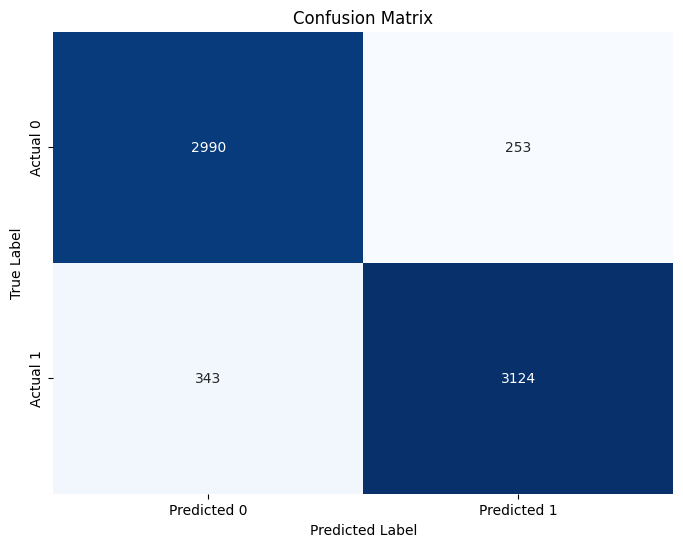

In [56]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate predictions on the test data
y_pred_probs = model_pretrained_embedding.predict(padded_testing_sequences)

# Convert probabilities to binary predictions (0 or 1)
y_pred_binary = (y_pred_probs > 0.5).astype(int)

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred_binary)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

The confusion matrix helps us understand the types of errors made by the model:

*   **True Negatives (Top-Left)**: Correctly predicted 0 (negative class).
*   **False Positives (Top-Right)**: Incorrectly predicted 1 (positive class) when the actual was 0.
*   **False Negatives (Bottom-Left)**: Incorrectly predicted 0 (negative class) when the actual was 1.
*   **True Positives (Bottom-Right)**: Correctly predicted 1 (positive class).

By examining these values, you can gain insight into the specific strengths and weaknesses of your model's classification performance.